# TP 5 - Apredizaje No Supervisado

## Sommelier de cerveza

El dataset contiene **1.5 millones de reportes de cervezas** scrappeados del sitio BeerAdvocates.

El objetivo es **agrupar los tipos de cervezas de acuerdo a dichos reportes** y **elegir una de ellas como la mejor representante de cada grupo**.

### Otras posibles preguntas

i) Si tuviésemos que elegir **las N más recomendables**,  
¿cuáles serían y por qué?

ii) ¿Cuáles son los **factores que más influyen en la calidad de una cerveza**?

### Dataset

https://github.com/manlio99/Materia_de_aprendizaje/tree/master/3_MidtermProjects/ProjectBEE


### Importar librerías

In [1]:
import numpy as np
import pandas as pd
import os
import requests
import time
import re
import string
from urllib.parse import urlparse


from tqdm import tqdm
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from glob import glob
from pathlib import Path


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import spacy

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.cluster import KMeans, SpectralClustering
import hdbscan

import umap

from wordcloud import WordCloud
from PIL import Image

from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap


from joblib import dump, load
import warnings

warnings.filterwarnings("ignore")

C:\Users\pablonicolasr\anaconda3\envs\am_uns\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
nltk.download("punkt")
nltk.download("stopwords")

In [2]:
path_data = os.path.join(os.getcwd(), "data")
path = Path(path_data)
path.mkdir(parents=True, exist_ok=True)

In [ ]:
urls = [
    "https://raw.githubusercontent.com/emmanueliarussi/DataScienceCapstone/master/3_MidtermProjects/ProjectBEE/data/beer_reviews_1.csv",
    "https://raw.githubusercontent.com/emmanueliarussi/DataScienceCapstone/master/3_MidtermProjects/ProjectBEE/data/beer_reviews_2.csv",
]

for url in urls:

    output_path = os.path.join(path_data, os.path.basename(urlparse(url).path))
    
    start_time = time.time()
    
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    total_size = int(response.headers.get("content-length", 0))
    chunk_size = 8192
    
    with open(output_path, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc="Downloading dataset"
    ) as pbar:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))
    
    elapsed = time.time() - start_time
    print(f"\nDownload completed in {elapsed:.2f} seconds")

In [3]:
STOPWORDS = set(stopwords.words("english"))

In [4]:
df1 = pd.read_csv(os.path.join(os.getcwd(), "data", "beer_reviews_1.csv"))
df2 = pd.read_csv(os.path.join(os.getcwd(), "data", "beer_reviews_2.csv"))

In [5]:
df1.head()

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,10325,Vecchio Birraio,1234817823,1.5,2.0,2.5,stcules,Hefeweizen,1.5,1.5,Sausa Weizen,5.0,47986
1,10325,Vecchio Birraio,1235915097,3.0,2.5,3.0,stcules,English Strong Ale,3.0,3.0,Red Moon,6.2,48213
2,10325,Vecchio Birraio,1235916604,3.0,2.5,3.0,stcules,Foreign / Export Stout,3.0,3.0,Black Horse Black Beer,6.5,48215
3,10325,Vecchio Birraio,1234725145,3.0,3.0,3.5,stcules,German Pilsener,2.5,3.0,Sausa Pils,5.0,47969
4,1075,Caldera Brewing Company,1293735206,4.0,4.5,4.0,johnmichaelsen,American Double / Imperial IPA,4.0,4.5,Cauldron DIPA,7.7,64883


In [6]:
df2.head()

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,147,Stone Brewing Co.,1283263116,4.0,4.0,4.0,Tilley4,American Barleywine,4.5,4.0,Stone Old Guardian Barley Wine Style Ale 2010,11.1,56068
1,147,Stone Brewing Co.,1283104309,4.0,4.0,4.0,kzoobrew,American Barleywine,4.5,4.0,Stone Old Guardian Barley Wine Style Ale 2010,11.1,56068
2,147,Stone Brewing Co.,1283041969,4.0,4.0,4.0,atsprings,American Barleywine,3.5,4.0,Stone Old Guardian Barley Wine Style Ale 2010,11.1,56068
3,147,Stone Brewing Co.,1282794993,4.5,4.0,3.5,dasenebler,American Barleywine,4.5,4.5,Stone Old Guardian Barley Wine Style Ale 2010,11.1,56068
4,147,Stone Brewing Co.,1282599829,4.0,4.0,4.0,JoEBoBpr,American Barleywine,4.0,4.5,Stone Old Guardian Barley Wine Style Ale 2010,11.1,56068


In [7]:
df = pd.concat([df1, df2])
df.head()

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,10325,Vecchio Birraio,1234817823,1.5,2.0,2.5,stcules,Hefeweizen,1.5,1.5,Sausa Weizen,5.0,47986
1,10325,Vecchio Birraio,1235915097,3.0,2.5,3.0,stcules,English Strong Ale,3.0,3.0,Red Moon,6.2,48213
2,10325,Vecchio Birraio,1235916604,3.0,2.5,3.0,stcules,Foreign / Export Stout,3.0,3.0,Black Horse Black Beer,6.5,48215
3,10325,Vecchio Birraio,1234725145,3.0,3.0,3.5,stcules,German Pilsener,2.5,3.0,Sausa Pils,5.0,47969
4,1075,Caldera Brewing Company,1293735206,4.0,4.5,4.0,johnmichaelsen,American Double / Imperial IPA,4.0,4.5,Cauldron DIPA,7.7,64883


# Inspección inicial: columnas, tipos, nulos, duplicados

In [8]:
print("Shape:", df.shape)

Shape: (1586614, 13)


In [9]:
display(df.dtypes)

brewery_id              int64
brewery_name              str
review_time             int64
review_overall        float64
review_aroma          float64
review_appearance     float64
review_profilename        str
beer_style                str
review_palate         float64
review_taste          float64
beer_name                 str
beer_abv              float64
beer_beerid             int64
dtype: object

In [10]:
# Nulos
na = df.isna().mean().sort_values(ascending=False)
display(na.head(20))

beer_abv              0.042723
review_profilename    0.000219
brewery_name          0.000009
brewery_id            0.000000
review_time           0.000000
review_overall        0.000000
review_aroma          0.000000
review_appearance     0.000000
beer_style            0.000000
review_palate         0.000000
review_taste          0.000000
beer_name             0.000000
beer_beerid           0.000000
dtype: float64

In [11]:
# Duplicados
dup = df.duplicated().mean()
print(f"% filas duplicadas: {dup*100:.3f}%")

% filas duplicadas: 0.000%


# Normalización nombres de columnas

In [12]:
df.columns

Index(['brewery_id', 'brewery_name', 'review_time', 'review_overall',
       'review_aroma', 'review_appearance', 'review_profilename', 'beer_style',
       'review_palate', 'review_taste', 'beer_name', 'beer_abv',
       'beer_beerid'],
      dtype='str')

# Conversión temporal (review_time)

In [13]:
df["review_time"] = pd.to_datetime(df["review_time"], unit="s")

df["review_year"] = df["review_time"].dt.year
df["review_month"] = df["review_time"].dt.month

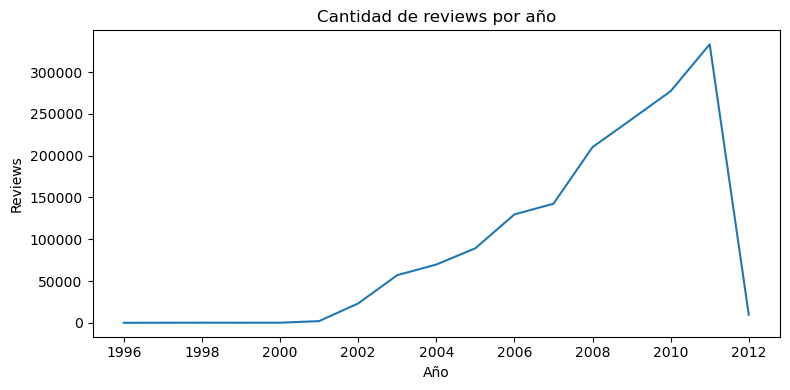

In [14]:
plt.figure(figsize=(8,4))
df["review_year"].value_counts().sort_index().plot()
plt.title("Cantidad de reviews por año")
plt.ylabel("Reviews")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

# Distribución de ratings (calidad percibida)

In [15]:
rating_cols = [
    "review_overall",
    "review_taste", # Qué tan rico resulta al probarlo
    "review_aroma", # Lo que se percibe antes de probar, al oler.
    "review_appearance", # Apariencia visual
    "review_palate", # Sensación en boca (mouthfeel)
]

df[rating_cols].describe()

,review_overall,review_taste,review_aroma,review_appearance,review_palate
count,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06
mean,3.815581e+00,3.792860e+00,3.735636e+00,3.841642e+00,3.743701e+00
std,7.206219e-01,7.319696e-01,6.976167e-01,6.160928e-01,6.822184e-01
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,3.500000e+00,3.500000e+00,3.500000e+00,3.500000e+00,3.500000e+00
50%,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
75%,4.500000e+00,4.500000e+00,4.000000e+00,4.000000e+00,4.000000e+00
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00


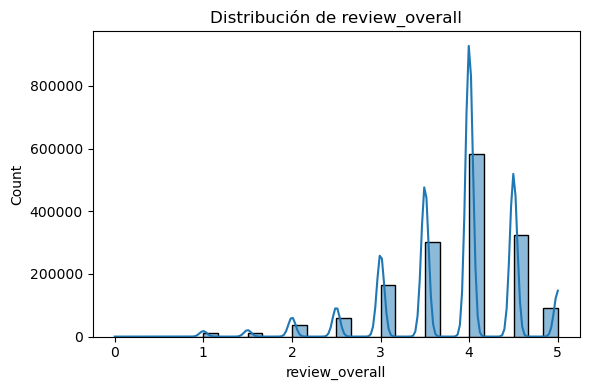

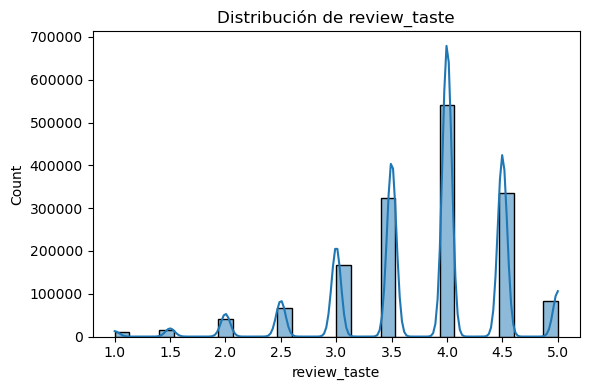

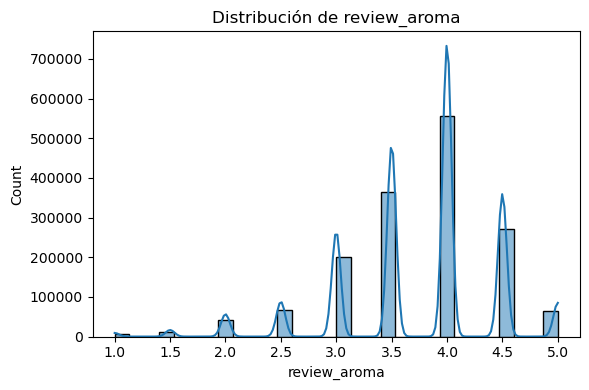

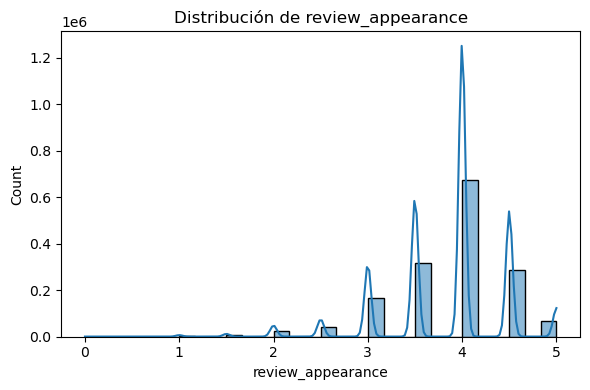

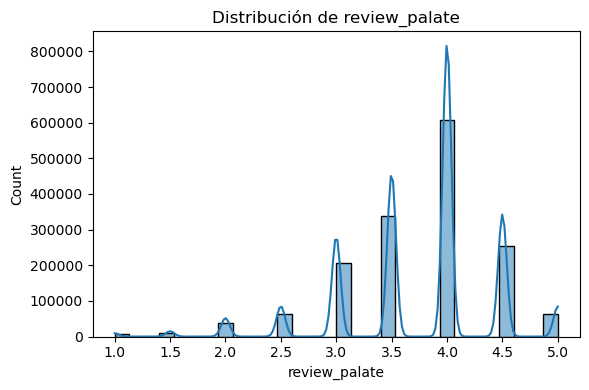

In [16]:
for col in rating_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.show()

# Correlación entre sub-ratings

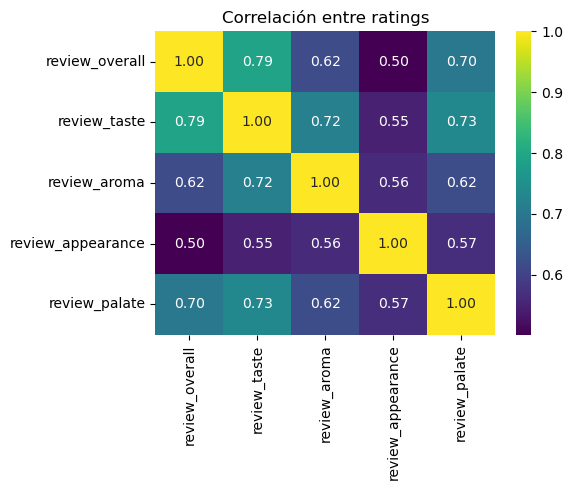

In [17]:
corr = df[rating_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlación entre ratings")
plt.tight_layout()
plt.show()

### El sabor es el principal determinante de la calidad percibida de una cerveza.

# ABV (graduación alcohólica)

In [18]:
df["beer_abv"].describe()

count    1.518829e+06
mean     7.042387e+00
std      2.322526e+00
min      1.000000e-02
25%      5.200000e+00
50%      6.500000e+00
75%      8.500000e+00
max      5.770000e+01
Name: beer_abv, dtype: float64

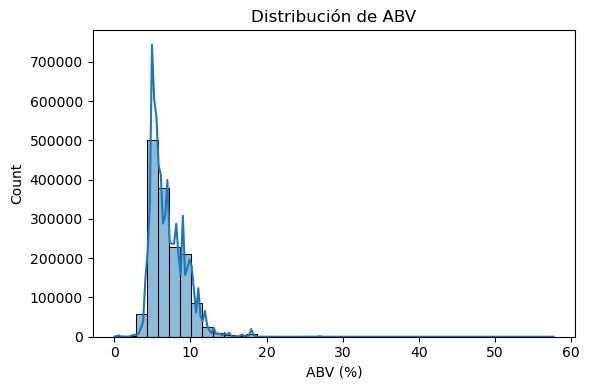

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df["beer_abv"].dropna(), bins=40, kde=True)
plt.title("Distribución de ABV")
plt.xlabel("ABV (%)")
plt.tight_layout()
plt.show()

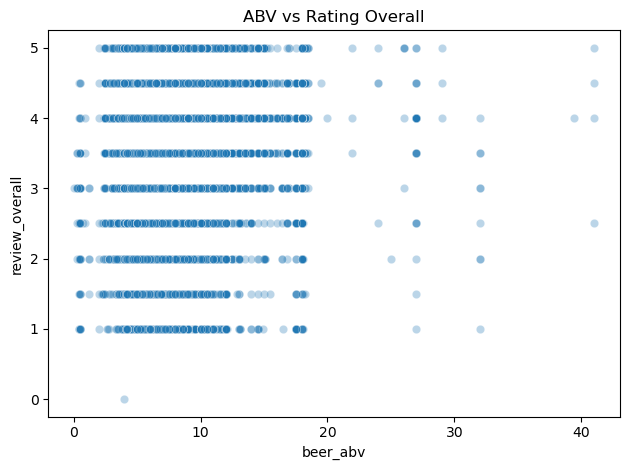

In [20]:
sns.scatterplot(
    data=df.sample(100_000, random_state=42).reset_index(drop=True),
    x="beer_abv",
    y="review_overall",
    alpha=0.3
)
plt.title("ABV vs Rating Overall")
plt.tight_layout()
plt.show()

# Estilos de cerveza (beer_style)

In [21]:
style_counts = df["beer_style"].value_counts()

style_counts.head(33)

beer_style
American IPA                        117586
American Double / Imperial IPA       85977
American Pale Ale (APA)              63469
Russian Imperial Stout               54129
American Double / Imperial Stout     50705
American Porter                      50477
American Amber / Red Ale             45751
Belgian Strong Dark Ale              37743
Fruit / Vegetable Beer               33861
American Strong Ale                  31945
Belgian Strong Pale Ale              31490
Saison / Farmhouse Ale               31480
American Adjunct Lager               30749
Tripel                               30328
Witbier                              30140
Hefeweizen                           27908
American Barleywine                  26728
American Brown Ale                   25297
American Stout                       24538
American Pale Wheat Ale              24204
Märzen / Oktoberfest                 23523
English Pale Ale                     23402
German Pilsener                      22155


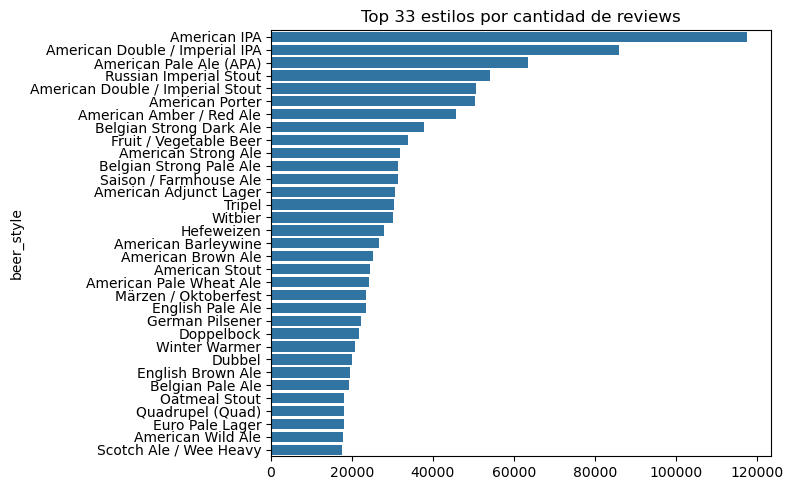

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=style_counts.head(33).values,
    y=style_counts.head(33).index
)
plt.title("Top 33 estilos por cantidad de reviews")
plt.tight_layout()
plt.show()

## Cervezas y cervecerías más evaluadas

In [23]:
df["beer_name"].value_counts().head(15)

beer_name
90 Minute IPA                                 3290
India Pale Ale                                3130
Old Rasputin Russian Imperial Stout           3111
Sierra Nevada Celebration Ale                 3000
Two Hearted Ale                               2728
Arrogant Bastard Ale                          2704
Stone Ruination IPA                           2704
Sierra Nevada Pale Ale                        2587
Stone IPA (India Pale Ale)                    2575
Pliny The Elder                               2527
Founders Breakfast Stout                      2502
Pale Ale                                      2500
Sierra Nevada Bigfoot Barleywine Style Ale    2492
La Fin Du Monde                               2483
60 Minute IPA                                 2475
Name: count, dtype: int64

In [24]:
df["brewery_name"].value_counts().head(15)

brewery_name
Boston Beer Company (Samuel Adams)    39444
Dogfish Head Brewery                  33839
Stone Brewing Co.                     33066
Sierra Nevada Brewing Co.             28751
Bell's Brewery, Inc.                  25191
Rogue Ales                            24083
Founders Brewing Company              20004
Victory Brewing Company               19479
Lagunitas Brewing Company             16837
Avery Brewing Company                 16107
Southern Tier Brewing Company         15868
Anheuser-Busch                        15815
Great Divide Brewing Company          14935
Goose Island Beer Co.                 14534
Three Floyds Brewing Co. & Brewpub    14039
Name: count, dtype: int64

## Variabilidad de calidad por estilo

In [25]:
style_stats = (
    df.groupby("beer_style")["review_overall"]
      .agg(["mean", "std", "count"])
      .sort_values("count", ascending=False)
)

style_stats.head(33)

,mean,std,count
beer_style,,,
American IPA,3.965221,0.610760,117586
American Double / Imperial IPA,3.998017,0.636758,85977
American Pale Ale (APA),3.852306,0.660452,63469
Russian Imperial Stout,4.023084,0.635446,54129
American Double / Imperial Stout,4.029820,0.666457,50705
American Porter,3.895735,0.643701,50477
American Amber / Red Ale,3.781010,0.670689,45751
Belgian Strong Dark Ale,3.913322,0.635337,37743
Fruit / Vegetable Beer,3.415124,0.891717,33861


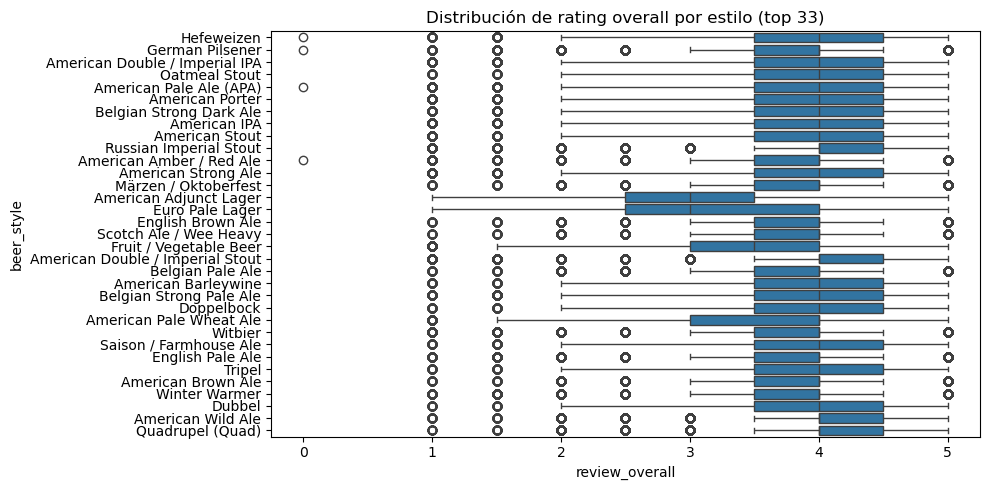

In [26]:
top_styles = style_stats.head(33).index

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df[df["beer_style"].isin(top_styles)],
    x="review_overall",
    y="beer_style"
)
plt.title("Distribución de rating overall por estilo (top 33)")
plt.tight_layout()
plt.show()

## ABV vs estilo (estructura real del espacio)

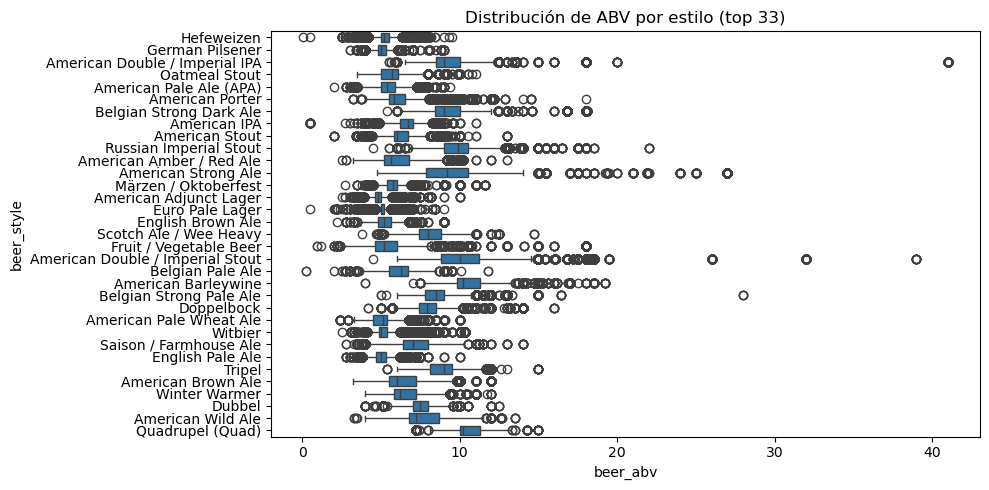

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df[df["beer_style"].isin(top_styles)].reset_index(drop=True),
    x="beer_abv",
    y="beer_style"
)
plt.title("Distribución de ABV por estilo (top 33)")
plt.tight_layout()
plt.show()

## Redundancia / dimensionalidad

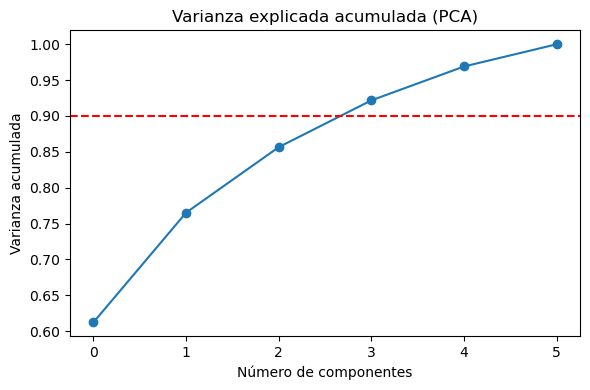

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = df[
    [
        "review_overall",
        "review_taste",
        "review_aroma",
        "review_appearance",
        "review_palate",
        "beer_abv",
    ]
].dropna()

X = StandardScaler().fit_transform(features)

pca = PCA()
pca.fit(X)

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.9, linestyle="--", color="red")
plt.title("Varianza explicada acumulada (PCA)")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.tight_layout()
plt.show()

# Conclusiones preliminares

El análisis exploratorio muestra que las puntuaciones de sabor (*review_taste*) y cuerpo (*review_palate*) son los factores más influyentes en la evaluación global (overall) de una cerveza, mientras que la apariencia tiene un impacto menor.

Existen diferencias claras entre estilos tanto en términos de calidad percibida como de graduación alcohólica, lo que sugiere una estructura subyacente en el espacio de características.

Asimismo, la correlación entre algunas nos indicamos que podemos aplicar alguna técnica de reducción de la dimensión.

Estos resultados indican que el dataset contiene suficiente información para agrupar cervezas de manera coherente y seleccionar representantes por grupo.

## Primero definimos el espacio de características

In [29]:
features_cols = [
    "review_taste",
    "review_aroma",
    "review_palate",
    "review_appearance",
    "review_overall",
    "beer_abv",
]

# columnas “ID” / metadata
id_cols = ["beer_beerid", "beer_name", "beer_style"]

# (filtramos filas válidas
tmp = df[id_cols + features_cols].dropna(subset=["beer_beerid"]).copy()

# agregamos por cerveza (1 fila = 1 cerveza) !important
beer = (
    tmp.groupby("beer_beerid", as_index=False)
       .agg(
           beer_name=("beer_name", "first"),
           beer_style=("beer_style", "first"),
           n_reviews=("review_overall", "size"),
           review_overall=("review_overall", "mean"),
           review_taste=("review_taste", "mean"),
           review_aroma=("review_aroma", "mean"),
           review_appearance=("review_appearance", "mean"),
           review_palate=("review_palate", "mean"),
           beer_abv=("beer_abv", "mean"),
       )
)

beer = beer.dropna(subset=["review_overall", "beer_abv"])
beer["log_n_reviews"] = np.log1p(beer["n_reviews"]) # la distribución es extremadamente sesgada, entonces se comprime las diferencias grandes y
# se mantiene las chicas

# agrupar los tipos de cervezas de acuerdo a dichos reportes
df_clust = beer[
    [
        "review_taste",
        "review_aroma",
        "review_palate",
        "review_appearance",
        "review_overall",
        "beer_abv",
        "log_n_reviews",
    ]
].copy()

print("Beer-level df_clust:", df_clust.shape)

Beer-level df_clust: (49012, 7)


## Normalización

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

## Reducción de dimensionalidad (PCA)

In [31]:
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Componentes retenidas:", pca.n_components_)

Componentes retenidas: 4


In [32]:
X_pca.shape

(49012, 4)

In [33]:
X_pca.shape

(49012, 4)

## Método del codo + Silhouette

In [34]:
inertias = []
sil_scores = []
K = range(2, 11)

rng = np.random.default_rng(42)
idx = rng.choice(X_pca.shape[0], size=min(20_000, X_pca.shape[0]), replace=False)
X_s = X_pca[idx]


for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)          # se entrena con todo el espacio de características
    inertias.append(km.inertia_)

    sil_scores.append(
        silhouette_score(X_s, labels[idx])  # silhouette solo en subset
    )

print(list(zip(K, sil_scores)))

[(2, 0.39202077529793183), (3, 0.25677481233239624), (4, 0.28509017888836535), (5, 0.27234657854334926), (6, 0.24690559945342666), (7, 0.21628160976772), (8, 0.21828403386680656), (9, 0.2218670849805977), (10, 0.21768763476576977)]


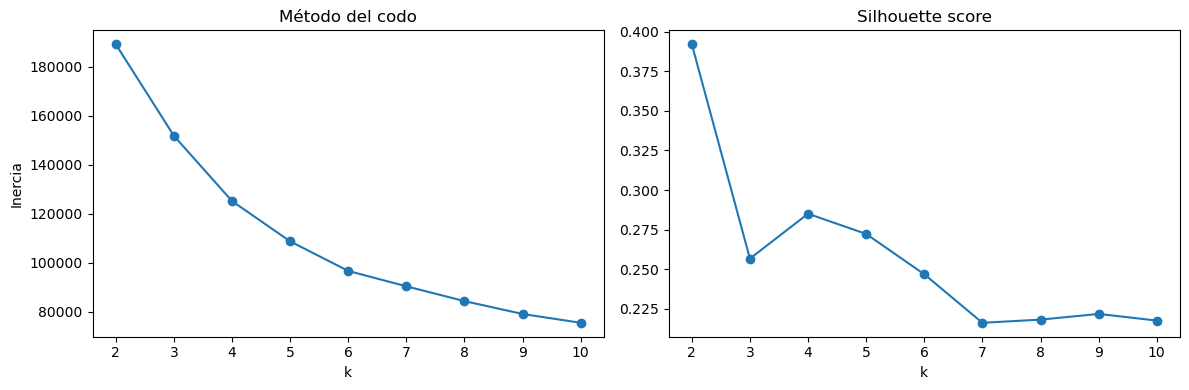

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(K, inertias, marker="o")
ax[0].set_title("Método del codo")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inercia")

ax[1].plot(K, sil_scores, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k")

plt.tight_layout()
plt.show()

In [36]:
km = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = km.fit_predict(X_pca)

In [37]:
# Adjuntamos labels al dataframe de cervezas
beer = beer.reset_index(drop=True).copy()
beer["cluster"] = labels

beer["cluster"].value_counts().sort_index()

cluster
0    17064
1    19043
2     5170
3     7735
Name: count, dtype: int64

In [38]:
# Perfil de cada cluster (tabla “sommelier”)
profile_cols = ["review_overall","review_taste","review_aroma","review_palate","review_appearance","beer_abv","n_reviews"]

cluster_profile = (
    beer.groupby("cluster")[profile_cols]
        .agg(["mean","median","std"])
)

# más legible: solo medias y tamaño
cluster_summary = (
    beer.groupby("cluster")
        .agg(
            size=("beer_beerid","count"),
            overall_mean=("review_overall","mean"),
            taste_mean=("review_taste","mean"),
            aroma_mean=("review_aroma","mean"),
            palate_mean=("review_palate","mean"),
            appearance_mean=("review_appearance","mean"),
            abv_mean=("beer_abv","mean"),
            n_reviews_mean=("n_reviews","mean"),
        )
        .sort_index()
)

cluster_summary

,size,overall_mean,taste_mean,aroma_mean,palate_mean,appearance_mean,abv_mean,n_reviews_mean
cluster,,,,,,,,
0,17064,3.448328,3.379204,3.352570,3.369439,3.537449,5.527918,6.746074
1,19043,4.098529,4.065911,3.962910,3.992751,3.989392,6.733266,3.600063
2,5170,2.449274,2.363936,2.456722,2.484466,2.832997,5.210561,13.150484
3,7735,3.847651,3.839784,3.804460,3.789917,3.885834,7.486653,163.822883


## Conclusiones preliminares

Se puede observar que el "rendimiento global" (overall), se relaciona estrechamente con el puntaje que describen al gusto, aroma, sensación en boca y apariencia. Aunque una mayor graduación de alcohol no implica un mayor "rendimiento global".

1. Cluster 0 --> Describen a cervezas "promedio", aquellas cervezas que consumiría la mayoría de personas.
2. Cluster 1 --> Representan cervezas de alta calidad, aunque poco conocidas. Podría ser que estén orientadas al consumo de personas con alto poder adquisitivo, o bien, cervezas artesanales.
3. Cluster 2 --> Describen a cervezas de baja calidad.
4. Cluster 3 --> Representan cervezas de alta calidad, pero consolidadas en el mercado.

In [39]:
# Elegimos la cerveza representante de cada cluster (medoid + calidad + confianza)
from sklearn.metrics import pairwise_distances

centers = km.cluster_centers_

D = pairwise_distances(X_pca, centers)  # (n_beers, k)

beer["dist_center"] = D[np.arange(D.shape[0]), beer["cluster"].values]

# score representante: calidad + confianza - distancia al centro
beer["log_n_reviews"] = np.log1p(beer["n_reviews"])
beer["rep_score"] = beer["review_overall"] + 0.10*beer["log_n_reviews"] - 0.25*beer["dist_center"]

representantes = (
    beer.sort_values("rep_score", ascending=False)
        .groupby("cluster", as_index=False)
        .head(1)
        .sort_values("cluster")
        [["cluster","beer_beerid","beer_name","beer_style","review_overall","n_reviews","beer_abv","dist_center","rep_score"]]
)

representantes

,cluster,beer_beerid,beer_name,beer_style,review_overall,n_reviews,beer_abv,dist_center,rep_score
17258,0,30289,Carls Ale (- 2009),American Pale Ale (APA),5.0000,1,5.2,1.126861,4.787599
33217,1,55078,Abijah Rowe,English India Pale Ale (IPA),5.0000,2,6.8,0.824965,4.903620
41443,2,67012,Liq Natural 10P,American Adjunct Lager,5.0000,1,3.6,3.164489,4.278192
9495,3,16814,Heady Topper,American Double / Imperial IPA,4.6258,469,8.0,2.892622,4.517917


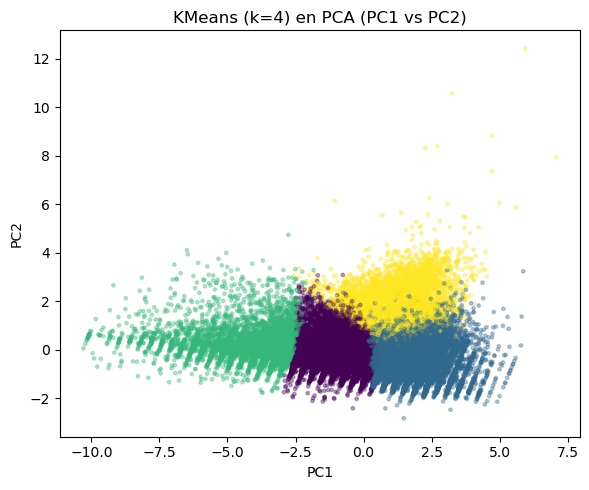

In [40]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=6, alpha=0.35)
plt.title("KMeans (k=4) en PCA (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Top-N “más recomendables”

In [44]:
def bayesian_score(R, v, C, m):
    return (v/(v+m))*R + (m/(v+m))*C

C = beer["review_overall"].mean()
m = int(np.percentile(beer["n_reviews"], 70))

beer["bayes_score"] = bayesian_score(
    R=beer["review_overall"], # rendimiento
    v=beer["n_reviews"], # votos 
    C=C, # promedio global del rendimiento
    m=m # evidencia mínima necesaria para ser evaluada
)

topN = (beer.sort_values("bayes_score", ascending=False)
           .head(20)[["beer_beerid","beer_name","beer_style","review_overall","n_reviews","bayes_score","cluster"]])

topN

,beer_beerid,beer_name,beer_style,review_overall,n_reviews,bayes_score,cluster
26432,44910,Dirty Horse,Lambic - Unblended,4.820513,39,4.643699,1
42545,68548,Armand'4 Oude Geuze Lente (Spring),Gueuze,4.730769,65,4.626530,1
991,1545,Trappist Westvleteren 12,Quadrupel (Quad),4.617925,1272,4.612674,3
9495,16814,Heady Topper,American Double / Imperial IPA,4.625800,469,4.611576,3
5066,8626,Southampton Berliner Weisse,Berliner Weissbier,4.768293,41,4.606461,1
33949,56082,Citra DIPA,American Double / Imperial IPA,4.630952,252,4.604672,3
12283,21690,Pliny The Younger,American Double / Imperial IPA,4.600000,610,4.589320,3
4702,7971,Pliny The Elder,American Double / Imperial IPA,4.590028,2527,4.587455,3
20798,36316,Cantillon Blåbær Lambik,Lambic - Fruit,4.628205,156,4.586565,3
35675,58610,Hoppy Birthday,American Pale Ale (APA),4.684615,65,4.584863,3


## Se puede observar que las más recomendadas pertenecen a los cluster que denominamos como cervezas de alta calidad.

### ¿Qué factores influyen más en la calidad?

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


X = beer[["review_taste","review_aroma","review_palate","review_appearance","beer_abv"]].copy()
y = beer["review_overall"].copy()

In [46]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(Xtr, ytr)
pred = model.predict(Xte)

print("R2:", r2_score(yte, pred))
print("MAE:", mean_absolute_error(yte, pred))

R2: 0.80751608112171
MAE: 0.18439312929417512


In [47]:
coefs = model.named_steps["ridge"].coef_
imp = pd.Series(coefs, index=X.columns).sort_values(key=np.abs, ascending=False)
imp

review_taste         0.364245
review_palate        0.163803
beer_abv            -0.065103
review_aroma         0.054834
review_appearance    0.022064
dtype: float64

### Para analizar los factores que influyen en la calidad global de una cerveza se utilizó un modelo de regresión Ridge. Este enfoque permite manejar adecuadamente la alta correlación entre las variables "sensoriales", evitando inestabilidades en los coeficientes y proporcionando una interpretación clara de la contribución relativa de cada factor.

El gusto es el factor dominante. 